Title: PSL_CMIP6_old_only_timesteps.ipynb

Purpose: Load psl data for event dates and plot some of them

Author: Onno Nennecke on 30.05.2025 Modified: 04.06.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
import cftime
# import datetime

# Importing functions
import Functions.grid_func as grid_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [3]:
ts_mean_psl_pm = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_slice/psl_mean_combined.nc')
ts_mean_psl_pm

<xarray.Dataset> Size: 97kB
Dimensions:   (ESM: 12, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * ESM       (ESM) <U10 480B 'ACCESS-CM2' 'BCC-CSM2-M' ... 'Combined'
Data variables:
    psl       (ESM, lat, lon) float32 96kB ...
Attributes:
    regrid_method:  bilinear

In [4]:
ts_mean_psl_pm.sel(ESM = 'ACCESS-CM2')

<xarray.Dataset> Size: 9kB
Dimensions:   (lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
    ESM       <U10 40B 'ACCESS-CM2'
Data variables:
    psl       (lat, lon) float32 8kB ...
Attributes:
    regrid_method:  bilinear

### Define used models

In [3]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
# Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
Institution = ['CSIRO-ARCCSS', 'BCC', 'NCAR', 'EC-Earth-Consortium', 'NOAA-GFDL', 'NIMS-KMA', 'DKRZ', 'MRI', 'AS-RCEC', 'MOHC', 'NIMS-KMA']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL', 'UKESM1-0-LL']

# ESMs = ['EC-Earth3'] # 'EC-Earth3-Veg'

scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax', 'psl'] # List of variables
# variables = 'psl'
grid_def = '*'
version = '*'


In [4]:
# read csv file
LEE_1 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_1.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_7.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/test_files/LEE_14.csv')


In [5]:
# Select one exemplary entry from LEE_1 for each ESM values
def select_exemplary_entries(LEE_df, ESMs):
    exemplary_entries = []
    for esm in ESMs:
        esm_entries = LEE_df[LEE_df['ESM'] == esm]
        if not esm_entries.empty:
            exemplary_entry = esm_entries.iloc[0]  # Select the first entry for each ESM
            exemplary_entries.append(exemplary_entry)
    return pd.DataFrame(exemplary_entries)
# LEE_1_subset = select_exemplary_entries(LEE_1, ESMs)
LEE_1_subset = LEE_1.copy()
# LEE_1_subset = LEE_1[0:10]
# LEE_1_subset

In [6]:
LEE_1[LEE_1['ESM_run'] == 'EC-Earth3_r15i1p1f1']

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter


In [7]:
LEE_1

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
0,2015-01-18 12:00:00,2015-01-18 12:00:00,2015-01-18 12:00:00.000000000,1421582400000000000,1421582400000000000,1421582400000000000,17,17,17,1,1373.585419,1373.585419,0.000000,1373.585419,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2014,110
1,2015-10-21 12:00:00,2015-10-21 12:00:00,2015-10-21 12:00:00.000000000,1445428800000000000,1445428800000000000,1445428800000000000,110,110,110,1,1378.601098,1378.601098,0.000000,1378.601098,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,21
2,2015-11-04 12:00:00,2015-11-05 12:00:00,2015-11-04 12:00:00.000000000,1446638400000000000,1446724800000000000,1446638400000000000,124,125,124,2,1404.935534,1401.253278,3.682256,2802.506556,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,35
3,2015-12-16 12:00:00,2015-12-17 12:00:00,2015-12-16 12:00:00.000000000,1450267200000000000,1450353600000000000,1450267200000000000,166,167,166,2,1454.631376,1415.495103,39.136273,2830.990205,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,77
4,2016-12-12 12:00:00,2016-12-12 12:00:00,2016-12-12 12:00:00.000000000,1481544000000000000,1481544000000000000,1481544000000000000,344,344,344,1,1428.634773,1428.634773,0.000000,1428.634773,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5321,2023-12-21 12:00:00,2023-12-21 12:00:00,2023-12-21 12:00:00.000000000,2023-12-22 12:00:00,2023-12-22 12:00:00,2023-12-22 12:00:00,1627,1627,1627,1,1378.105975,1378.105975,0.000000,1378.105975,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,82
5322,2023-12-23 12:00:00,2023-12-23 12:00:00,2023-12-23 12:00:00.000000000,2023-12-24 12:00:00,2023-12-24 12:00:00,2023-12-24 12:00:00,1629,1629,1629,1,1409.127953,1409.127953,0.000000,1409.127953,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,84
5323,2024-01-25 12:00:00,2024-01-25 12:00:00,2024-01-25 12:00:00.000000000,2024-01-27 12:00:00,2024-01-27 12:00:00,2024-01-27 12:00:00,1662,1662,1662,1,1390.731921,1390.731921,0.000000,1390.731921,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,117
5324,2024-11-14 12:00:00,2024-11-14 12:00:00,2024-11-14 12:00:00.000000000,2024-11-15 12:00:00,2024-11-15 12:00:00,2024-11-15 12:00:00,1772,1772,1772,1,1399.713515,1399.713515,0.000000,1399.713515,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,45


In [8]:
def preprocess(ds, s = 20, n = 90, w = 270, e = 90):
    if e < w:
        part1 = ds.sel(lon=slice(w, 360))
        part2 = ds.sel(lon=slice(0, e))
        europe = xr.concat([part1, part2], dim="lon")
        ds = europe.sel(lat=slice(s, n))
    else:
        ds = ds.sel(lat=slice(s, n), lon=slice(w, e))
    return ds

In [ ]:
# Takes about 
variable = 'psl'
ds_list = [] # List to hold individual datasets 
LEE_1_subset_check = LEE_1_subset.copy() # Copy to check later if all runs are found
# for ESM in ESMs:
for ESM, Inst in zip(ESMs, Institution):
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    runs = os.listdir(matching_dirs[0])
    print('Runs: ', runs)
    for run in runs:
        ESM_run = f'{ESM}_{run}'
        print('ESM_run: ', ESM_run)
        if ESM_run in LEE_1_subset['ESM_run'].values:
            LEE_1_subset_run = LEE_1_subset[LEE_1_subset['ESM_run'] == ESM_run]
            LEE_1_subset_check = LEE_1_subset_check[LEE_1_subset_check['ESM_run'] != ESM_run] # Remove found run from check
        else:
            print('skip')
            continue
        # print(LEE_1_subset_run)

        run_time = time.time()
        print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
        # print('Open: ', path)
        
        # Filter out files with extensions after .nc
        files = [f for f in glob.glob(path) if f.endswith('.nc')]
        
        # Open with preprocessing (spatial filtering)
        if files:
            nc = xr.open_mfdataset(files, preprocess=preprocess)
        else:
            print("No valid .nc files found!")
            
        # Keep only the desired variable, but retain Dataset structure
        nc = nc[[variable]]
        
        # Filter to only winter months (October to March)
        # nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

        # Filter years
        nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
        
        # Filter only desired days
        # dates = pd.to_datetime(LEE_1_subset_run['date_start'].values).date
        date_strings = LEE_1_subset_run['date_start_old'].values

        # Identify the type of datetime used in the dataset
        time_type = type(nc.time.values[0])

        if isinstance(date_strings, str):
            date_list = [date_strings]
        else:
            date_list = list(date_strings)

        if time_type == np.datetime64:
            ns_ints = np.array(date_list, dtype=np.int64) # Turn your list of ns‐since‐epoch strings into an int64 NumPy array
            dt64 = ns_ints.astype("datetime64[ns]") # Cast that array to numpy datetime64[ns]
            dates = pd.DatetimeIndex(dt64) # wrap in a pandas DatetimeIndex

        elif isinstance(nc.time.values[0], cftime.DatetimeNoLeap):
            dates = []  # Initialize an empty list to hold the cftime objects
            for ds in date_list:
                # split "YYYY-MM-DD hh:mm:ss" into date & time parts
                date_part, time_part = ds.split(" ")
                # parse year, month, day
                year, month, day = map(int, date_part.split("-"))
                # parse hour, minute, second
                hour, minute, second = map(int, time_part.split(":"))
                # directly build the 360-day cftime object
                dates.append(cftime.DatetimeNoLeap(year, month, day, hour, minute, second))
            # dates = [cftime.DatetimeNoLeap(*(datetime.strptime(ds, "%Y-%m-%d %H:%M:%S").timetuple()[:6])) for ds in date_list]

        elif isinstance(nc.time.values[0], cftime.Datetime360Day):
            dates = []  # Initialize an empty list to hold the cftime objects
            for ds in date_list:
                # split "YYYY-MM-DD hh:mm:ss" into date & time parts
                date_part, time_part = ds.split(" ")
                # parse year, month, day
                year, month, day = map(int, date_part.split("-"))
                # parse hour, minute, second
                hour, minute, second = map(int, time_part.split(":"))
                # directly build the 360-day cftime object
                dates.append(cftime.Datetime360Day(year, month, day, hour, minute, second))

            # dates = [cftime.Datetime360Day(*(datetime.strptime(ds, "%Y-%m-%d %H:%M:%S").timetuple()[:6]))for ds in date_list]

        else:
            raise TypeError(f"Unsupported time type: {time_type}")

        # if time_type == np.datetime64:
        #     # Standard datetime
        #     dates = pd.to_datetime(int(date_strings))
        #     # dates = pd.to_datetime(date_strings)
        # elif isinstance(nc.time.values[0], cftime.DatetimeNoLeap):
        #     # Convert using DatetimeNoLeap
        #     dt = datetime.strptime(date_strings[0], '%Y-%m-%d %H:%M:%S')
        #     dates = cftime.DatetimeNoLeap(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
        #     # dates = [cftime.DatetimeNoLeap(*pd.to_datetime(d).timetuple()[:6]) for d in date_strings]
        # elif isinstance(nc.time.values[0], cftime.Datetime360Day):
        #     # Convert using Datetime360Day
        #     dt = datetime.strptime(date_strings[0], '%Y-%m-%d %H:%M:%S')
        #     dates = cftime.Datetime360Day(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
        #     # dates = [cftime.Datetime360Day(*pd.to_datetime(d).timetuple()[:6]) for d in date_strings]
        # else:
        #     raise TypeError(f"Unsupported time type: {time_type}")

        # Now select the times from the dataset
        selected = nc.sel(time=dates)
        
        # Regrid the combined dataset
        regridded_ds = grid_func.regrid(selected, s = 30, n = 70, w = 340, e = 30)
        
        ts_output = regridded_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')

        # nc = nc.sel(time=nc.time.dt.date.isin(pd.to_datetime(LEE_1_subset_run['date_start'].values).date))
        
        # Append to list for later merging
        ds_list.append(ts_output)
        
        # # Combine all into a single dataset
        # clim_ds = xr.merge(ds_list)

        # Apply bias correction ???
        # clim_ds['psl'] = clim_ds['sfcWind'] - biases.loc[biases['ESM'] == ESM, 'bias_sfcWind'].values[0]
            
        # Regrid the combined dataset
        # combined_ds = grid_func.regrid(clim_ds)
        
        # ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        # print('Load')
        # nc.load()
        # print('Saving')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected/full_year/{ESM}_{run}_timeseries.nc')
        # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked/full_year/{ESM}_{run}_timeseries.nc')
        
        print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
        # print('Finished saving')
    #     break
    # break

ESM:  ACCESS-CM2
Runs:  ['r4i1p1f1', 'r5i1p1f1', 'r1i1p1f1']
ESM_run:  ACCESS-CM2_r4i1p1f1
Run:  r4i1p1f1 Number:  1 of  3
Run time:  0 m 12.8 s
ESM_run:  ACCESS-CM2_r5i1p1f1
Run:  r5i1p1f1 Number:  2 of  3
Run time:  0 m 8.1 s
ESM_run:  ACCESS-CM2_r1i1p1f1
Run:  r1i1p1f1 Number:  3 of  3
Run time:  0 m 10.2 s
ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
ESM_run:  BCC-CSM2-MR_r1i1p1f1
Run:  r1i1p1f1 Number:  1 of  1
Run time:  0 m 28.1 s
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
ESM_run:  CESM2_r4i1p1f1
Run:  r4i1p1f1 Number:  1 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Run time:  0 m 0.6 s
ESM_run:  CESM2_r10i1p1f1
Run:  r10i1p1f1 Number:  2 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Run time:  0 m 0.5 s
ESM_run:  CESM2_r11i1p1f1
Run:  r11i1p1f1 Number:  3 of  3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Run time:  0 m 0.6 s
ESM:  EC-Earth3
Runs:  ['r149i1p1f1', 'r6i1p1f1', 'r4i1p1f1', 'r148i1p1f1', 'r105i1p1f1', 'r9i1p1f1', 'r134i1p1f1', 'r141i1p1f1', 'r146i1p1f1', 'r15i1p1f1', 'r112i1p1f1', 'r117i1p1f1', 'r125i1p1f1', 'r113i1p1f1', 'r106i1p1f1', 'r138i1p1f1', 'r5i1p1f1', 'r137i1p1f1', 'r11i1p1f1', 'r145i1p1f1', 'r114i1p1f1', 'r120i1p1f1', 'r128i1p1f1', 'r135i1p1f1', 'r110i1p1f1', 'r129i1p1f1', 'r132i1p1f1', 'r101i1p1f1', 'r124i1p1f1', 'r127i1p1f1', 'r116i1p1f1', 'r131i1p1f1', 'r121i1p1f1', 'r142i1p1f1', 'r102i1p1f1', 'r133i1p1f1', 'r111i1p1f1', 'r140i1p1f1', 'r136i1p1f1', 'r108i1p1f1', 'r130i1p1f1', 'r150i1p1f1', 'r104i1p1f1', 'r118i1p1f1', 'r109i1p1f1', 'r143i1p1f1', 'r147i1p1f1', 'r126i1p1f1', 'r13i1p1f1', 'r119i1p1f1', 'r1i1p1f1', 'r123i1p1f1', 'r122i1p1f1', 'r115i1p1f1', 'r103i1p1f1', 'r144i1p1f1', 'r139i1p1f1', 'r107i1p1f1']
ESM_run:  EC-Earth3_r149i1p1f1
Run:  r149i1p1f1 Number:  1 of  58
Run time:  0 m 3.0 s
ESM_run:  EC-Earth3_r6i1p1f1
skip
ESM_run:  EC-Earth3_r4i1p1f1
Run:  

In [10]:
LEE_1_subset_check

,date_start,date_end,date_peak,date_start_old,date_end_old,date_peak_old,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
3299,2015-01-19 12:00:00,2015-01-23 12:00:00,2015-01-19 12:00:00.000000001,1421625600000000000,1421971200000000000,1421712000000000000,18,22,19,5,1477.760987,1444.025359,32.351758,7220.126795,ERA5_week,ERA5_hist_week,2014,111
3300,2015-02-04 12:00:00,2015-02-04 12:00:00,2015-02-04 12:00:00.000000000,1423008000000000000,1423008000000000000,1423008000000000000,34,34,34,1,1400.191382,1400.191382,0.000000,1400.191382,ERA5_week,ERA5_hist_week,2014,127
3301,2015-02-11 12:00:00,2015-02-12 12:00:00,2015-02-11 12:00:00.000000000,1423612800000000000,1423699200000000000,1423612800000000000,41,42,41,2,1409.298563,1404.209557,5.089006,2808.419114,ERA5_week,ERA5_hist_week,2014,134
3302,2015-02-17 12:00:00,2015-02-17 12:00:00,2015-02-17 12:00:00.000000000,1424131200000000000,1424131200000000000,1424131200000000000,47,47,47,1,1397.006202,1397.006202,0.000000,1397.006202,ERA5_week,ERA5_hist_week,2014,140
3303,2015-10-17 12:00:00,2015-10-17 12:00:00,2015-10-17 12:00:00.000000000,1445040000000000000,1445040000000000000,1445040000000000000,106,106,106,1,1379.281918,1379.281918,0.000000,1379.281918,ERA5_week,ERA5_hist_week,2015,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3513,2024-11-29 12:00:00,2024-11-29 12:00:00,2024-11-29 12:00:00.000000000,1732838400000000000,1732838400000000000,1732838400000000000,1787,1787,1787,1,1474.428985,1474.428985,0.000000,1474.428985,ERA5_wwd,ERA5_hist_wwd,2024,60
3514,2024-12-04 12:00:00,2024-12-04 12:00:00,2024-12-04 12:00:00.000000000,1733270400000000000,1733270400000000000,1733270400000000000,1792,1792,1792,1,1448.460402,1448.460402,0.000000,1448.460402,ERA5_wwd,ERA5_hist_wwd,2024,65
3515,2024-12-11 12:00:00,2024-12-13 12:00:00,2024-12-11 12:00:00.000000001,1733875200000000000,1734048000000000000,1733961600000000000,1799,1801,1800,3,1557.411659,1540.115728,19.641598,4620.347185,ERA5_wwd,ERA5_hist_wwd,2024,72
3516,2024-12-24 12:00:00,2024-12-24 12:00:00,2024-12-24 12:00:00.000000000,1734998400000000000,1734998400000000000,1734998400000000000,1812,1812,1812,1,1407.909766,1407.909766,0.000000,1407.909766,ERA5_wwd,ERA5_hist_wwd,2024,85


In [11]:
5107 + 219

5326

In [12]:
count = 0
for i in range(len(ds_list)):
    # print('Dataset: ', i, 'ESM_run: ', ds_list[i]['ESM'].values)
    # Count the number of times each ESM appears in the list
    count += ds_list[i].sizes['time']
count
# ds_list[21]['ESM_run'].values

5107

In [13]:
# 1) pull out the psl, override time → simple 0…N−1
da_list = []
step = 0
for ds in ds_list:
    da = ds['psl']
    # replace the datetime index by a simple integer index 0…Nt−1
    da = da.assign_coords(time=np.arange(da.sizes['time']) + step)
    step += da.sizes['time']  # update step for the next dataset
    da_list.append(da)

# 2) concatenate all of them along that “time” axis
combined = xr.concat(da_list, dim='time')

# 3) if you don’t even want to call it “time” anymore:
combined = combined.rename({'time':'sample'})
combined
# now `combined` is a DataArray of shape
#    (sample = sum(all runs’ timesteps), lat=12, lon=7)


<xarray.DataArray 'psl' (sample: 5107, lat: 70, lon: 180)> Size: 257MB
dask.array<concatenate, shape=(5107, 70, 180), dtype=float32, chunksize=(50, 70, 48), chunktype=numpy.ndarray>
Coordinates:
  * lat       (lat) int64 560B 20 21 22 23 24 25 26 27 ... 83 84 85 86 87 88 89
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 1kB 270 271 272 273 274 275 276 ... 84 85 86 87 88 89
    run       (sample) <U10 204kB 'r4i1p1f1' 'r4i1p1f1' ... 'r14i1p1f2'
    ESM       (sample) <U13 266kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    ESM_run   (sample) <U23 470kB 'ACCESS-CM2_r4i1p1f1' ... 'UKESM1-0-LL_r14i...
  * sample    (sample) int64 41kB 0 1 2 3 4 5 ... 5101 5102 5103 5104 5105 5106

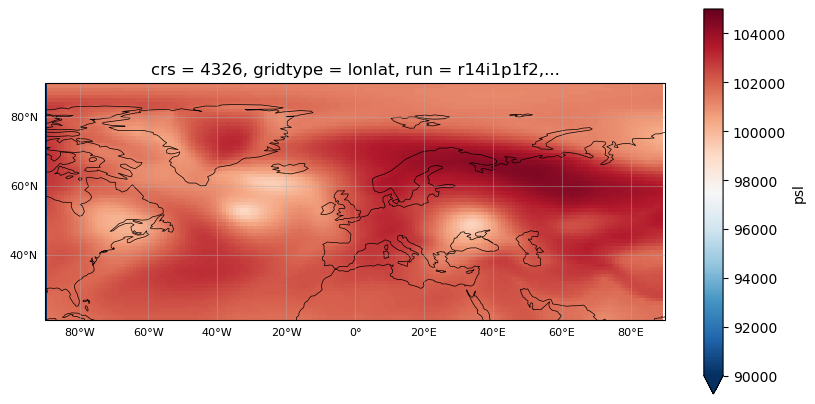

In [14]:
new_lon = ((da.lon + 180) % 360) - 180

# assign and then sort
da2 = (
    combined.assign_coords(lon=new_lon)
)
# Plot
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-90, 90, 21, 90], crs=ccrs.PlateCarree())
setup_gridlines(ax, deg=20, alpha=0.4)
# Add coastlines and gridlines
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# Plot the data
da2.isel(sample = 2).plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = 90000, vmax = 105000)
# da2.isel(sample=0).sel(lat=slice(21,90), lon=slice(-89,89)).plot(ax = ax, transform=ccrs.PlateCarree(), cmap='RdBu_r')




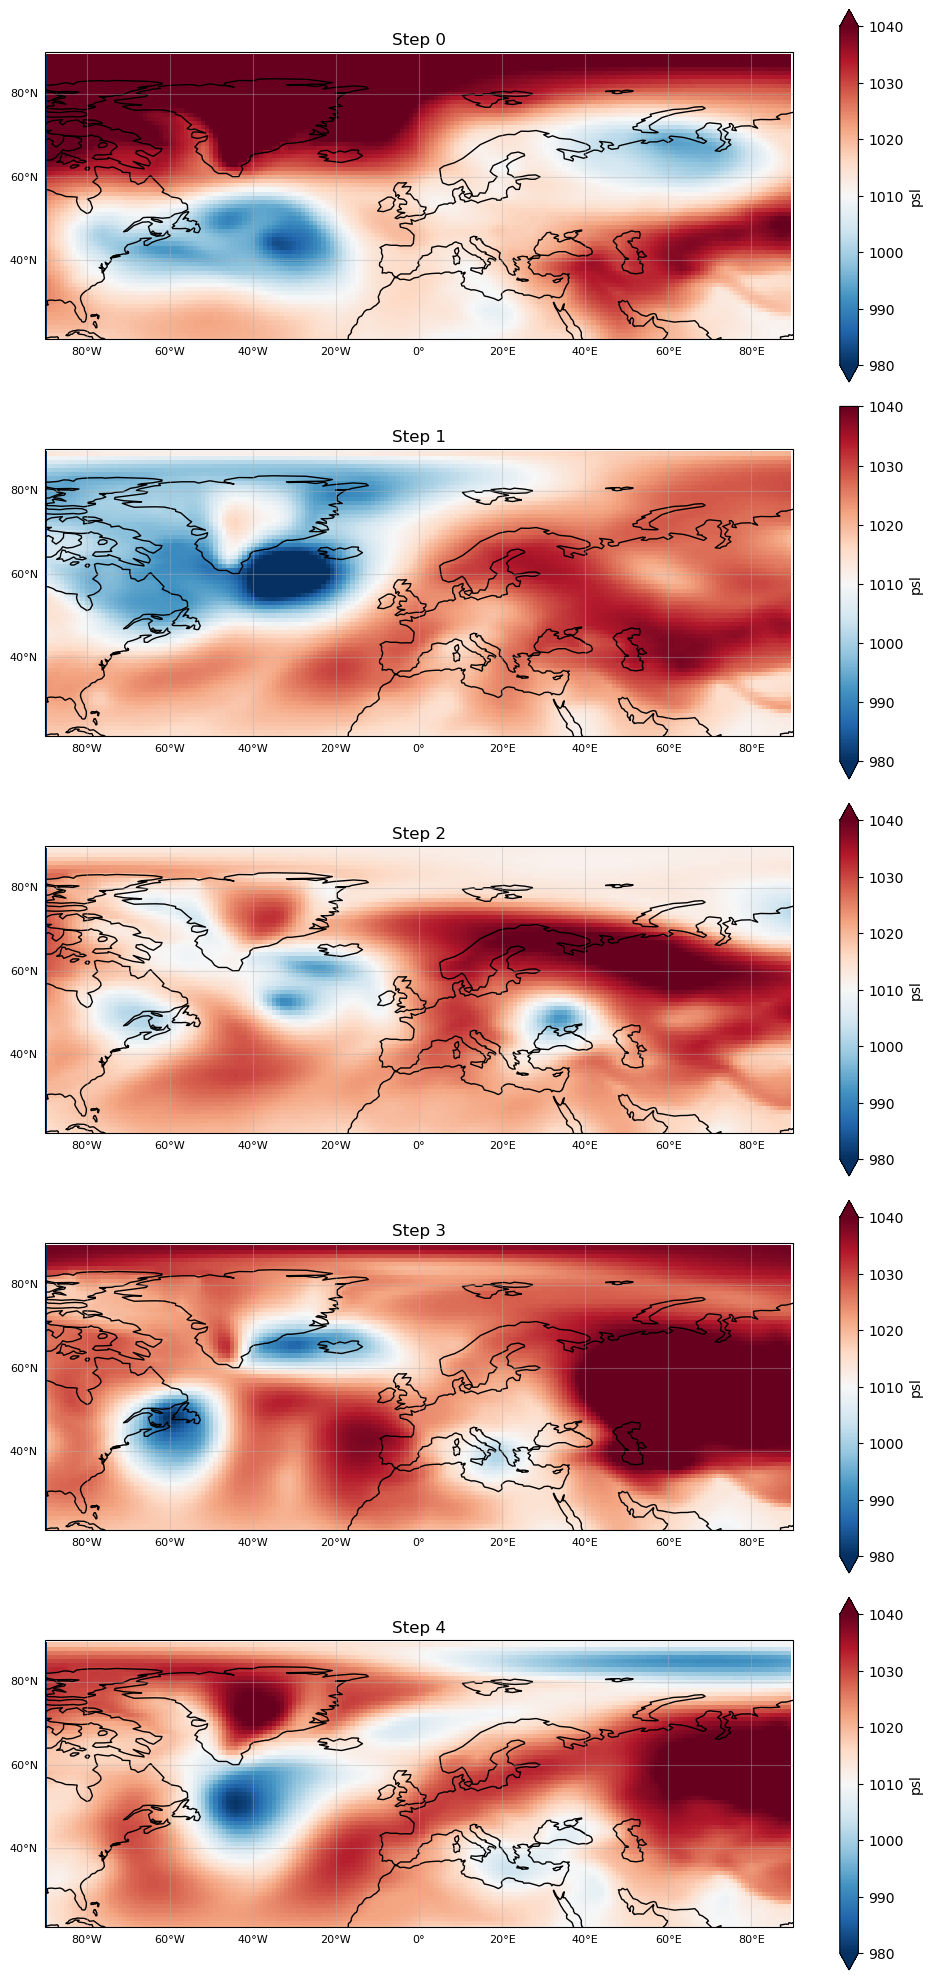

In [15]:
# Plot timesteps 0:4 as maps
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(10, 20), subplot_kw={'projection': ccrs.PlateCarree()})
for i, ax in enumerate(axes):
    step = da2.isel(sample=i) / 100
    ax.set_extent([-90, 90, 21, 90], crs=ccrs.PlateCarree())
    step.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = 980, vmax = 1040)
    ax.set_title(f'Step {i}')
    ax.add_feature(cfeature.COASTLINE)
    setup_gridlines(ax)
    # No legend
plt.tight_layout()
plt.show()

#### Try to plot a composite

In [16]:
composite = da2.mean(dim='sample')
composite_100 = composite / 100  # Convert to hPa
composite_100.load()


<xarray.DataArray 'psl' (lat: 70, lon: 180)> Size: 50kB
array([[   0.     ,    0.     ,    0.     , ...,    0.     ,    0.     ,
           0.     ],
       [ 793.82495, 1015.945  , 1016.06274, ..., 1015.0104 , 1014.8658 ,
        1014.76904],
       [ 794.2062 , 1016.3719 , 1016.4366 , ..., 1015.1806 , 1014.91296,
        1014.7815 ],
       ...,
       [ 791.8954 , 1014.4856 , 1014.46436, ..., 1014.961  , 1014.98846,
        1015.01556],
       [ 791.96716, 1014.5784 , 1014.56305, ..., 1014.92114, 1014.9386 ,
        1014.9562 ],
       [ 792.0682 , 1014.7111 , 1014.7039 , ..., 1014.88   , 1014.88806,
        1014.89734]], dtype=float32)
Coordinates:
  * lat       (lat) int64 560B 20 21 22 23 24 25 26 27 ... 83 84 85 86 87 88 89
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    run       <U9 36B 'r14i1p1f2'
    ESM       <U11 44B 'UKESM1-0-LL'
    ESM_run   <U21 84B 'UKESM1-0-LL_r14i1p1f2'
  * lon       (lon) int64 1kB -90 -89 -88 -87 -86 -85 -84 ... 84 85 86 87 88 89

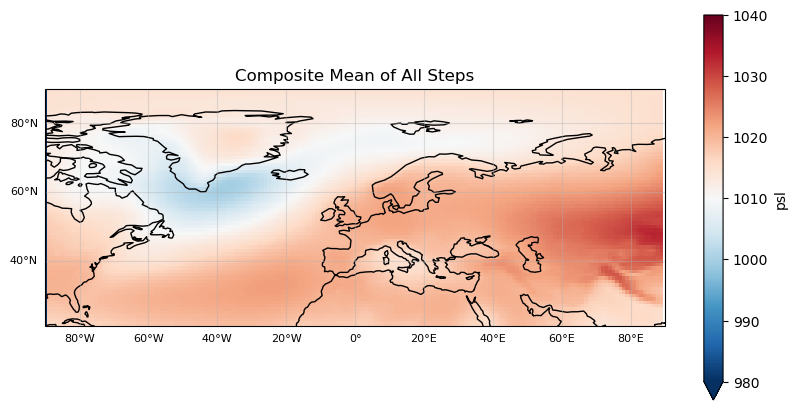

In [17]:
# Plot the composite map
fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-90, 90, 21, 90], crs=ccrs.PlateCarree())
composite_100.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = 980, vmax = 1040)
ax.set_title('Composite Mean of All Steps')
ax.add_feature(cfeature.COASTLINE)
setup_gridlines(ax)
plt.show()

#### Just some test plotting

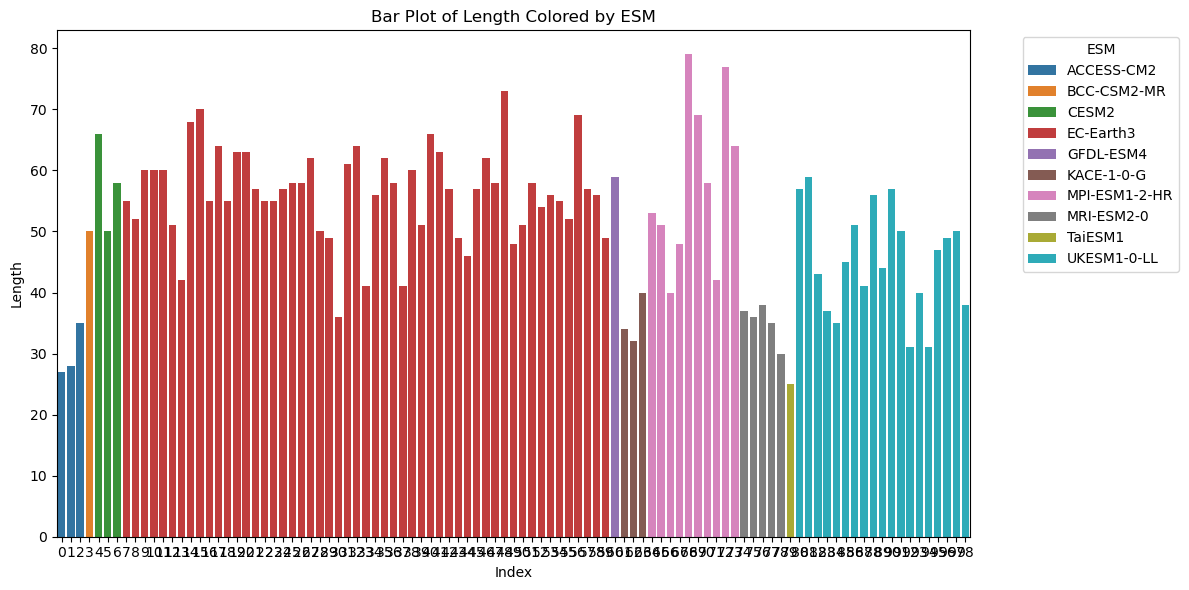

In [136]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

length = []
ESMs_list = []
for i in ds_list:
    length.append(len(i.time))
    ESMs_list.append(str(i.ESM.values))


# Replace this with your actual data loading
data = {
    'length': length,
    'ESM': ESMs_list
}
df = pd.DataFrame(data)

# Add an index column to plot against
df['Index'] = df.index

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Index', y='length', hue='ESM', dodge=False)
plt.xlabel('Index')
plt.ylabel('Length')
plt.title('Bar Plot of Length Colored by ESM')
plt.legend(title='ESM', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [21]:
# path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
run = 'r1i1p1f1'  # Example run, adjust as needed

path = f'/climca/data/CMIP6/{MIP}/{Institution[0]}/{ESMs[0]}/{scenario}/{run}/{time_res}/psl/{grid_def}/{version}/psl_{time_res}_{ESMs[0]}_{scenario}_{run}_*'


# Filter out files with extensions after .nc
files = [f for f in glob.glob(path) if f.endswith('.nc')]

def preprocess(ds, s = 45, n = 60, w = 270, e = 90):
    part1 = ds.sel(lon=slice(w, 360))
    part2 = ds.sel(lon=slice(0, e))
    europe = xr.concat([part1, part2], dim="lon")
    ds = europe.sel(lat=slice(s, n))
    return ds

nc = xr.open_mfdataset(files, preprocess=lambda ds: preprocess(ds, s=20, n=90, w=270, e=90))

nc = nc[['psl']]


# Filter to only winter months (October to March)
# nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

# Filter years
nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))
nc

<xarray.Dataset> Size: 79MB
Dimensions:  (time: 3653, lat: 56, lon: 96)
Coordinates:
  * time     (time) datetime64[ns] 29kB 2015-01-01T12:00:00 ... 2024-12-31T12...
  * lat      (lat) float64 448B 20.62 21.88 23.12 24.38 ... 86.88 88.12 89.38
  * lon      (lon) float64 768B 270.9 272.8 274.7 276.6 ... 85.31 87.19 89.06
Data variables:
    psl      (time, lat, lon) float32 79MB dask.array<chunksize=(1, 56, 48), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            ScenarioMIP AerChemMIP
    branch_method:          standard
    branch_time_in_child:   60265.0
    branch_time_in_parent:  60265.0
    creation_date:          2019-11-08T10:43:34Z
    ...                     ...
    variable_id:            psl
    variant_label:          r1i1p1f1
    version:                v20191108
    cmor_version:           3.4.0
    tracking_id:            hdl:21.14100/7f7c4a50-2ad2-41a4-916b-2a4a7a7380ae
    license:                CMIP6 model data produced by CSIRO is licensed un...

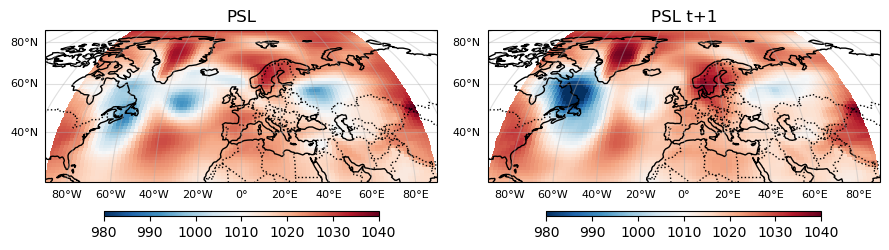

In [ ]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)

# '''
lon_edges = nc['lon'].values
lat_edges = nc['lat'].values

# Plot the data
timestep = 0# 29937# 1# 10000 # 24507

vmin = 980
vmax = 1040

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = nc['psl'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1 /100, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = vmin, vmax = vmax)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('PSL')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = nc['psl'].isel(time=timestep +1)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2/100, transform=ccrs.PlateCarree(), cmap='RdBu_r', vmin = vmin, vmax = vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('PSL t+1')

plt.tight_layout()
plt.show()
# '''

In [156]:
# Takes about 
variable = 'psl'
ds_list = [] # List to hold individual datasets 

# for ESM in ESMs:
for ESM, Inst in zip(ESMs, Institution):
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    runs = os.listdir(matching_dirs[0])
    # print('Runs: ', runs)
    for run in runs:
        ESM_run = f'{ESM}_{run}'
        # print('ESM_run: ', ESM_run)
        if ESM_run in LEE_1_subset['ESM_run'].values:
            LEE_1_subset_run = LEE_1_subset[LEE_1_subset['ESM_run'] == ESM_run]
        else:
            # print('skip')
            continue
        # print(LEE_1_subset_run)

        run_time = time.time()
        # print('Run: ', run, 'Number: ', runs.index(run) + 1, 'of ', len(runs))
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            # print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            # print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        path = f'/climca/data/CMIP6/{MIP}/{Inst}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
        # print('Open: ', path)
        
        # Filter out files with extensions after .nc
        files = [f for f in glob.glob(path) if f.endswith('.nc')]
        
        # Open with preprocessing (spatial filtering)
        if files:
            nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
        else:
            print("No valid .nc files found!")
            
        # Keep only the desired variable, but retain Dataset structure
        nc = nc[[variable]]
        print(nc.lat.values[1]-nc.lat.values[0])
        print(nc.lon.values[1]-nc.lon.values[0])
        # continue

        break
    # break

ESM:  ACCESS-CM2
1.25
1.875
ESM:  BCC-CSM2-MR
1.1214840568574118
1.125
ESM:  CESM2
0.9424083769633569
1.25
ESM:  EC-Earth3


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'psl' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


0.7017516609802996
0.703125
ESM:  GFDL-ESM4
1.0
1.25
ESM:  KACE-1-0-G
1.25
1.875
ESM:  MPI-ESM1-2-HR
0.9350584410882803
0.9375
ESM:  MRI-ESM2-0
1.1214799999999983
1.125
ESM:  TaiESM1
0.9424083769633569
1.25
ESM:  UKESM1-0-LL
1.25
1.875
ESM:  UKESM1-0-LL
1.25
1.875


In [150]:
nc.lat.values

array([45.625, 46.875, 48.125, 49.375, 50.625, 51.875, 53.125, 54.375,
       55.625, 56.875, 58.125, 59.375])